<a href="https://colab.research.google.com/github/chourouk-sun/CaliforniaHousingPrices-using-ML-/blob/main/CaliforniaHousingPrices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Housing** **Price** **Prediction** **using** **Machine** **Learning**

## Objective
The goal of this project is to predict the median house value in California districts
using demographic and geographic features.


In [ ]:
#Import Libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [ ]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

# Load dataset from scikit-learn
data = fetch_california_housing(as_frame=True)

# Features + target together
df = data.frame

df.head()
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')

In [ ]:
#Data Exploration
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [ ]:
#Target & Features Definition
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]


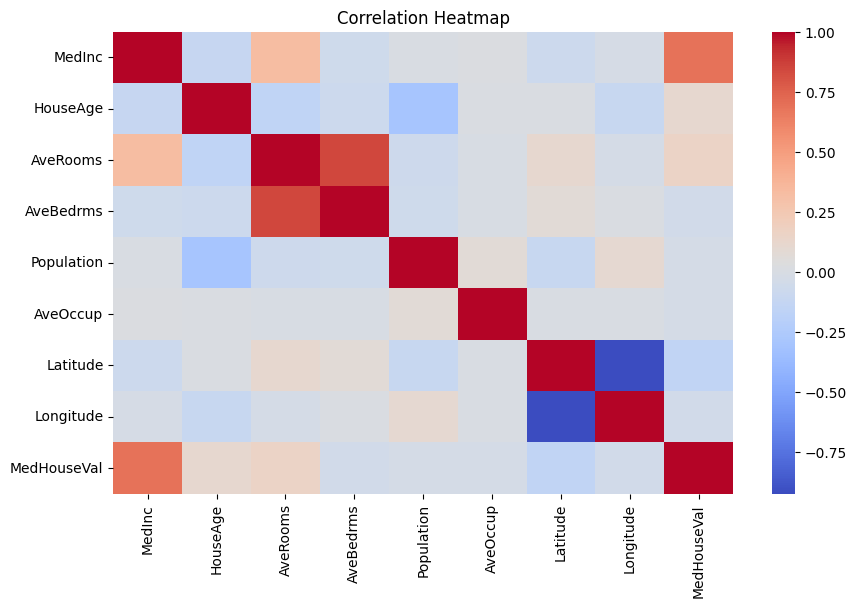

In [ ]:
#Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


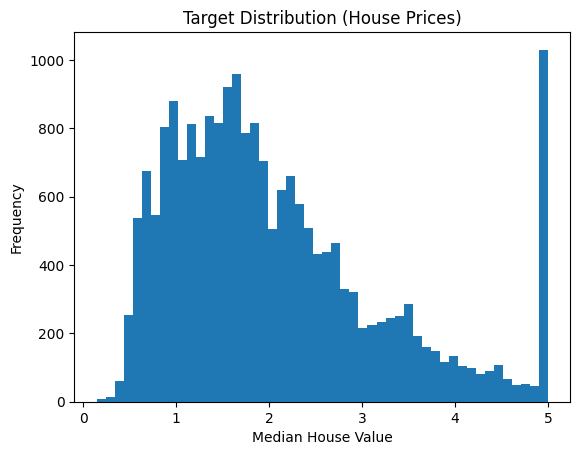

In [ ]:
#Target Distribution
plt.hist(df["MedHouseVal"], bins=50)
plt.title("Target Distribution (House Prices)")
plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.show()

In [ ]:
#Train / Test Split
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
#Baseline Model – Linear Regression
lr_pipeline = Pipeline ([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

In [ ]:
#Evaluation
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print("Linear Regression Results")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R²:", r2_lr)

Linear Regression Results
MAE: 0.5332001304956565
RMSE: 0.7455813830127763
R²: 0.575787706032451


In [ ]:
#Random Forest Regressor (Best Model)
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)


In [ ]:
#Evaluation
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R²:", r2_rf)




Random Forest Results
MAE: 0.32681185043604677
RMSE: 0.5039602414072009
R²: 0.8061857564039718


In [ ]:
#Model Comparison Table
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae_lr, mae_rf],
    "RMSE": [rmse_lr, rmse_rf],
    "R²": [r2_lr, r2_rf]
})

results


,Model,MAE,RMSE,R²
0,Linear Regression,0.533200,0.745581,0.575788
1,Random Forest,0.326812,0.503960,0.806186


In [ ]:
#Feature Importance
importances = rf.feature_importances_
features = X.columns

fi = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

fi


,Feature,Importance
0,MedInc,0.525886
5,AveOccup,0.138055
6,Latitude,0.088647
7,Longitude,0.088307
1,HouseAge,0.054355
2,AveRooms,0.044449
4,Population,0.030693
3,AveBedrms,0.029608


In [ ]:
feature_importance = pd.Series(
    model.coef_, index=X.columns
).sort_values()

feature_importance.plot(kind="barh", figsize=(8,5))
plt.title("Feature Importance (Linear Regression)")
plt.show()


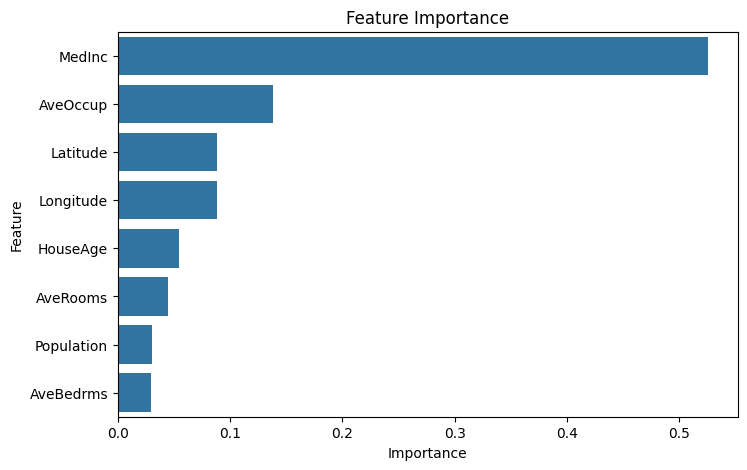

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", data=fi)
plt.title("Feature Importance")
plt.show()

In [ ]:
#Prediction of House Price
new_house = pd.DataFrame({
    "MedInc": [6.5],
    "HouseAge": [20],
    "AveRooms": [5.5],
    "AveBedrms": [1.1],
    "Population": [1500],
    "AveOccup": [3.0],
    "Latitude": [34.05],
    "Longitude": [-118.25]
})


In [ ]:
predicted_price = rf.predict(new_house)

print("Predicted Median House Value:", predicted_price[0])


Predicted Median House Value: 3.437786299999997


In [ ]:
predicted_price[0] * 100000


np.float64(343778.6299999997)

In [ ]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values[:10],
    "Predicted Price": y_pred_rf[:10]
})

comparison

,Actual Price,Predicted Price
0,0.47700,0.494430
1,0.45800,0.735655
2,5.00001,4.877332
3,2.18600,2.549705
4,2.78000,2.258135
5,1.58700,1.651050
6,1.98200,2.392525
7,1.57500,1.663745
8,3.40000,2.680615
9,4.46600,4.887244


📌 التفسير:

القيم يجب أن تكون قريبة نسبيًا

ليست متطابقة (وهذا طبيعي)

إذا رأيتِ أرقامًا عشوائية جدًا → مشكلة
إذا كانت قريبة → النموذج يتعلم 👍

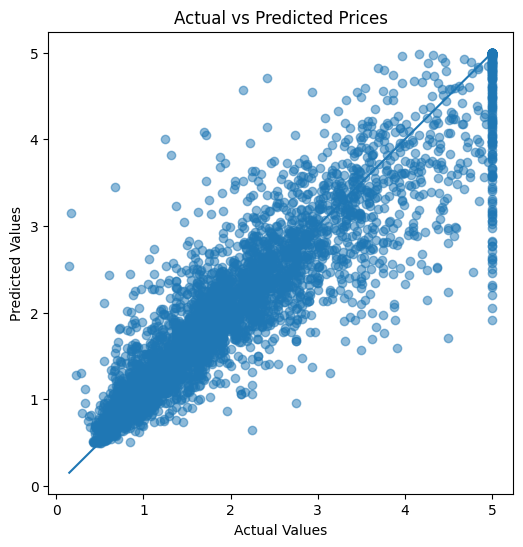

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Prices")
plt.show()


📌 التفسير:

النقاط يجب أن تكون قريبة من الخط

كلما اقتربت = نموذج أفضل

🔥 هذا الرسم يعجب جدًا في المقابلات

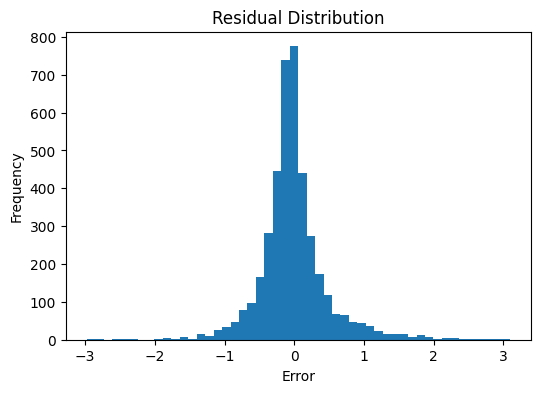

In [ ]:
residuals = y_test - y_pred_rf

plt.figure(figsize=(6,4))
plt.hist(residuals, bins=50)
plt.title("Residual Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

📌 التفسير:

الأخطاء متمركزة حول الصفر → ممتاز

انحراف قوي → مشكلة في النموذج

In [ ]:
new_house = pd.DataFrame({
    "MedInc": [6.5],
    "HouseAge": [20],
    "AveRooms": [5.5],
    "AveBedrms": [1.1],
    "Population": [1500],
    "AveOccup": [3.0],
    "Latitude": [34.05],
    "Longitude": [-118.25]
})

predicted_price = rf.predict(new_house)

print("Predicted Median House Value:", predicted_price[0])
print("Predicted Price in USD:", predicted_price[0] * 100000)

Predicted Median House Value: 3.437786299999997
Predicted Price in USD: 343778.6299999997


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importances = rf.feature_importances_
features = X.columns

feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
0,MedInc,0.525886
5,AveOccup,0.138055
6,Latitude,0.088647
7,Longitude,0.088307
1,HouseAge,0.054355
2,AveRooms,0.044449
4,Population,0.030693
3,AveBedrms,0.029608


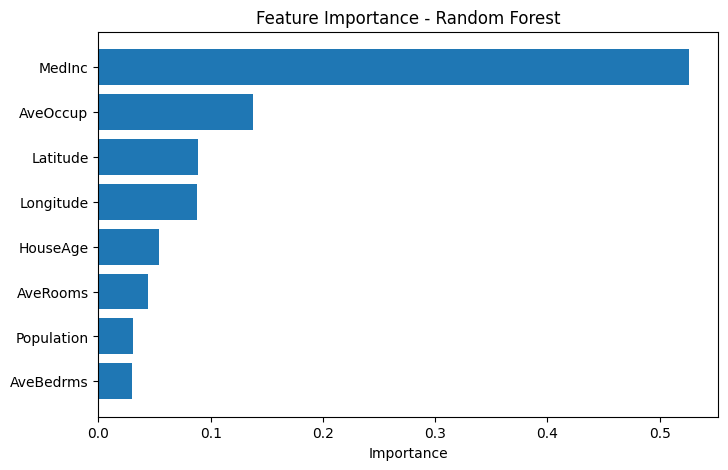

In [ ]:
plt.figure(figsize=(8,5))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.show()


📌 كيف تتحققين؟

MedInc غالبًا الأعلى → منطقي ✔

الموقع (Latitude, Longitude) مهم → منطقي ✔

🗣️ في المقابلة:

The model shows that median income and location
are the most influential factors in housing prices.

🗣️ في المقابلة:

The model shows that median income and location
are the most influential factors in housing prices.

In [ ]:
predicted_price[0]


np.float64(3.437786299999997)

✨ تفسير جاهز للاستخدام:

The predicted house price is mainly driven by
high median income and favorable geographic location,
while house age and population density had less impact.

🔥 هذا تفسير ذكي وبسيط — لا تحتاج SHAP في مستوى Junior

In [ ]:
base_prediction = rf.predict(new_house)[0]


In [ ]:
new_house_high_income = new_house.copy()
new_house_high_income["MedInc"] = 10  # increase income

rf.predict(new_house_high_income)


array([4.7882727])

📌 إذا:

السعر زاد → النموذج منطقي ✔

لم يتغير → مشكلة ❌

👉 هذا أفضل اختبار سريع للثقة بالنموذج.

In [ ]:
print("Base prediction:", base_prediction)
print("High income prediction:", new_house_high_income)

print("Difference:", new_house_high_income - base_prediction)


Base prediction: 3.437786299999997
High income prediction:    MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      10        20       5.5        1.1        1500       3.0     34.05   

   Longitude  
0    -118.25  
Difference:      MedInc   HouseAge  AveRooms  AveBedrms   Population  AveOccup   Latitude  \
0  6.562214  16.562214  2.062214  -2.337786  1496.562214 -0.437786  30.612214   

    Longitude  
0 -121.687786  


In [ ]:
# Base prediction
base_prediction = rf.predict(new_house)[0]

# New house with higher income
new_house_high_income = new_house.copy()
new_house_high_income["MedInc"] = 10
high_income_prediction = rf.predict(new_house_high_income)[0]

# Difference
difference = high_income_prediction - base_prediction

# Print clearly
print("Base prediction (100k$):", base_prediction)
print("High income prediction (100k$):", high_income_prediction)
print("Difference (100k$):", difference)
print("Base prediction in USD:", base_prediction*100000)
print("High income prediction in USD:", high_income_prediction*100000)
print("Difference in USD:", difference*100000)


Base prediction (100k$): 3.4377862999999964
High income prediction (100k$): 4.788272699999989
Difference (100k$): 1.3504863999999923
Base prediction in USD: 343778.62999999966
High income prediction in USD: 478827.26999999885
Difference in USD: 135048.63999999923


🗣️ ماذا تقولين في المقابلة 🇩🇪

I tested the model with a higher median income value and verified that the predicted house price increased logically,
showing the model is consistent with real-world expectations.

🔥 هذا يُظهر نضجك كـ Junior Data Scientist

🔹 قراءة النتائج
وصف	القيمة (100k$)	القيمة بالدولار
Base prediction	3.4378	343,779$
High income prediction	4.7883	478,827$
Difference	1.3505	135,049$

✅ ماذا يعني هذا؟

عندما زدنا MedInc من 6.5 → 10، ارتفع السعر المتنبأ به من 343k$ → 478k$

الفرق ≈ 135k$، وهذا منطقي اقتصاديًا لأن الدخل المرتفع يزيد من قيمة المنازل في المنطقة.

🔹 ماذا يدل هذا؟

1️⃣ النموذج منطقي: التغييرات في الميزات المهمة (MedInc) تؤثر على التنبؤ كما نتوقع
2️⃣ النموذج قابل للتفسير: يمكنك ربط Feature Importance بالقيمة المتوقعة
3️⃣ جاهز للـ Sanity Check وكتابة فقرة Model Validation في README

🔹 كيف تكتبينها في README / GitHub
### Sanity Check / Prediction Example

We tested the model by increasing the median income (MedInc)
from 6.5 to 10 for a hypothetical district.

- Base prediction: 343,779 USD
- High income prediction: 478,827 USD
- Difference: 135,049 USD

This confirms that the model responds logically to important features
and is consistent with real-world expectations.

🔹 ماذا تقولين في المقابلة 🇩🇪

I performed a sanity check by increasing median income for a hypothetical district.
The predicted house price increased by around $135k,
confirming the model behaves logically and is interpretable.

🔥 هذه إجابة قوية جدًا للـ Junior Data Scientist

إذا أحببت، أستطيع الآن أن أجهز لك Notebook كامل جاهز للـ GitHub

كل خطوة محسوبة

Evaluation ✅

Sanity check ✅

Feature importance ✅

Prediction جاهزة للاستخدام

هل تريدين أن أفعل ذلك الآن؟